# Análisis del Comportamiento de Honestidad en un Experimento

Este notebook contiene un análisis exhaustivo de los resultados de un experimento sobre honestidad. Se cargan los datos, se preprocesan, se comparan con un benchmark racional, se visualizan patrones, se realizan análisis estadísticos detallados y se exploran simulaciones de diferentes estrategias.

sacar datos

## 1. Carga y Preprocesamiento de Datos

En esta sección, cargamos los datos del experimento y realizamos las operaciones iniciales de limpieza y preparación, incluyendo el filtrado de participantes incompletos y la creación de variables derivadas clave como `is_lie` (si el participante mintió) y `lie_magnitude` (la magnitud de la mentira).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Cargar datos
df = pd.read_csv('rounds.csv')

# Filtrar pruebas y sesiones incompletas
df = df[df['id'] >= 89].copy()
completos = df.groupby('participant_id').size()
ids_completos = completos[completos == 15].index
df = df[df['participant_id'].isin(ids_completos)].copy()

# Variables derivadas
df['is_lie'] = (df['v_d'] > df['v_r']).astype(int)
df['lie_magnitude'] = df['v_d'] - df['v_r']

print(f"Participantes: {df['participant_id'].nunique()}")
print(f"Observaciones: {len(df)}")
print(df.groupby('block')['is_lie'].mean().round(3))

Participantes: 48
Observaciones: 720
block
1    0.588
2    0.404
3    0.258
Name: is_lie, dtype: float64


benchmark racional

## 2. Benchmark Racional

Aquí definimos un modelo de agente puramente racional y neutral al riesgo para establecer un benchmark. Este agente decide mentir o ser honesto basándose únicamente en la maximización de su utilidad esperada, considerando la probabilidad de auditoría `P` en cada bloque. Esto nos permite comparar el comportamiento humano con una referencia teórica óptima.

In [3]:
# ── BENCHMARK RACIONAL ──────────────────────────────────────────────────────
# Función de utilidad esperada del agente neutral al riesgo:
# EU(Honestidad)    = v_r
# EU(Deshonestidad) = (1-P)*v_d + P*(v_r - v_d)
#
# El agente miente si EU(Deshonestidad) > EU(Honestidad)
# Derivando EU respecto a v_d:
#   ∂EU/∂v_d = 1 - 2P
#
# Si 1-2P > 0  (P < 0.5) → mentir al máximo es óptimo
# Si 1-2P = 0  (P = 0.5) → mentir es indiferente
# Si 1-2P < 0  (P > 0.5) → ser honesto es óptimo

print("=" * 55)
print("DERIVACIÓN DEL BENCHMARK RACIONAL")
print("=" * 55)

bloques = {1: 0.2, 2: 0.5, 3: 0.8}

for bloque, P in bloques.items():
    derivada = round(1 - 2*P, 1)
    if derivada > 0:
        decision = "Mentir al máximo → v_d = 10"
        tasa = 1.0
    elif derivada == 0:
        decision = "Indiferente → v_d = v_r (honesto por defecto)"
        tasa = 0.0
    else:
        decision = "Ser honesto → v_d = v_r"
        tasa = 0.0
    print(f"\nBloque {bloque} (P={P})")
    print(f"  ∂EU/∂v_d = 1 - 2×{P} = {derivada}")
    print(f"  Decisión óptima: {decision}")
    print(f"  Tasa de mentira racional: {tasa*100:.0f}%")

# Guardamos las tasas racionales para usarlas en los gráficos
benchmark = {1: 1.0, 2: 0.0, 3: 0.0}
print("\n✓ Benchmark definido:", benchmark)

DERIVACIÓN DEL BENCHMARK RACIONAL

Bloque 1 (P=0.2)
  ∂EU/∂v_d = 1 - 2×0.2 = 0.6
  Decisión óptima: Mentir al máximo → v_d = 10
  Tasa de mentira racional: 100%

Bloque 2 (P=0.5)
  ∂EU/∂v_d = 1 - 2×0.5 = 0.0
  Decisión óptima: Indiferente → v_d = v_r (honesto por defecto)
  Tasa de mentira racional: 0%

Bloque 3 (P=0.8)
  ∂EU/∂v_d = 1 - 2×0.8 = -0.6
  Decisión óptima: Ser honesto → v_d = v_r
  Tasa de mentira racional: 0%

✓ Benchmark definido: {1: 1.0, 2: 0.0, 3: 0.0}


El cálculo del benchmark racional nos da las tasas de mentira esperadas para cada bloque bajo un comportamiento puramente egoísta y maximizador.

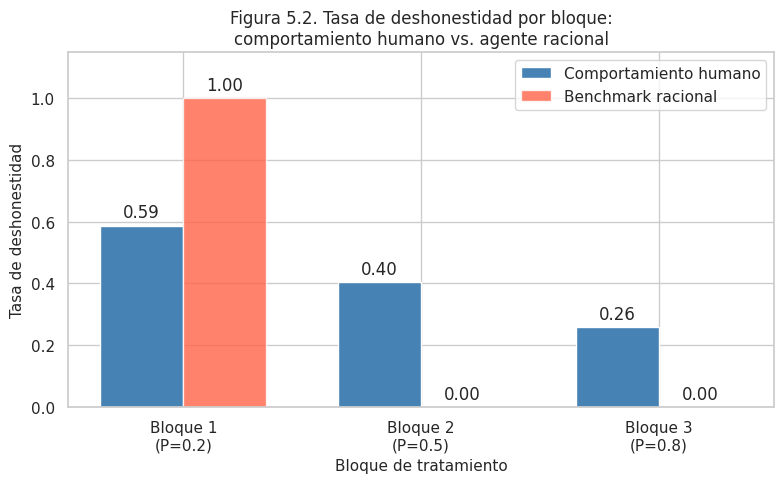

In [4]:
# ── FIGURA 5.2: Tasa de deshonestidad por bloque: humanos vs. benchmark racional ──
tasa_humana = df.groupby('block')['is_lie'].mean().values
tasa_racional = [benchmark[1], benchmark[2], benchmark[3]]
bloques_labels = ['Bloque 1\n(P=0.2)', 'Bloque 2\n(P=0.5)', 'Bloque 3\n(P=0.8)']

x = np.arange(len(bloques_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, tasa_humana, width, label='Comportamiento humano', color='steelblue')
bars2 = ax.bar(x + width/2, tasa_racional, width, label='Benchmark racional', color='tomato', alpha=0.8)

ax.set_ylabel('Tasa de deshonestidad')
ax.set_xlabel('Bloque de tratamiento')
ax.set_title('Figura 5.2. Tasa de deshonestidad por bloque:\ncomportamiento humano vs. agente racional')
ax.set_xticks(x)
ax.set_xticklabels(bloques_labels)
ax.set_ylim(0, 1.15)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)

plt.tight_layout()
plt.savefig('figura_5_2.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Visualización de Resultados Clave

Esta sección presenta una serie de gráficos para explorar visualmente los patrones de deshonestidad en el experimento. Analizamos la tasa de mentira por bloque, la influencia del valor real, las curvas de declaración y la evolución temporal de la deshonestidad.

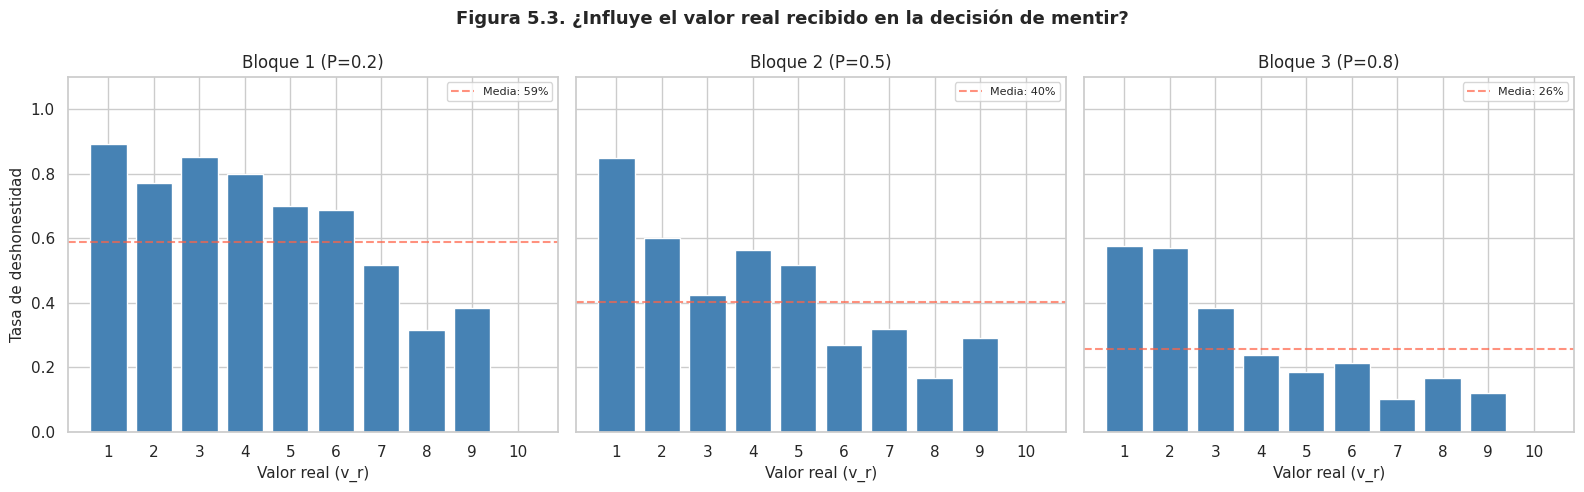

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 1: ¿INFLUYE EL VALOR REAL EN LA DECISIÓN DE MENTIR?
# ══════════════════════════════════════════════════════════════════════════════
# Hipótesis: si te toca un valor bajo (1, 2, 3) tienes más incentivo a mentir
# porque la diferencia entre tu carta y el 10 es mayor

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, b in enumerate([1, 2, 3]):
    ax = axes[i]
    datos_b = df[df['block'] == b]
    tasa_por_vr = datos_b.groupby('v_r')['is_lie'].mean()
    ax.bar(tasa_por_vr.index, tasa_por_vr.values, color='steelblue', edgecolor='white')
    ax.set_xlabel('Valor real (v_r)')
    ax.set_title(f'Bloque {b} (P={[0.2,0.5,0.8][b-1]})')
    ax.set_xticks(range(1, 11))
    ax.set_ylim(0, 1.1)
    # Línea media
    media = datos_b['is_lie'].mean()
    ax.axhline(y=media, color='tomato', linestyle='--', alpha=0.7,
               label=f'Media: {media:.0%}')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Tasa de deshonestidad')
plt.suptitle('Figura 5.3. ¿Influye el valor real recibido en la decisión de mentir?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figura_5_3.png', dpi=150, bbox_inches='tight')
plt.show()

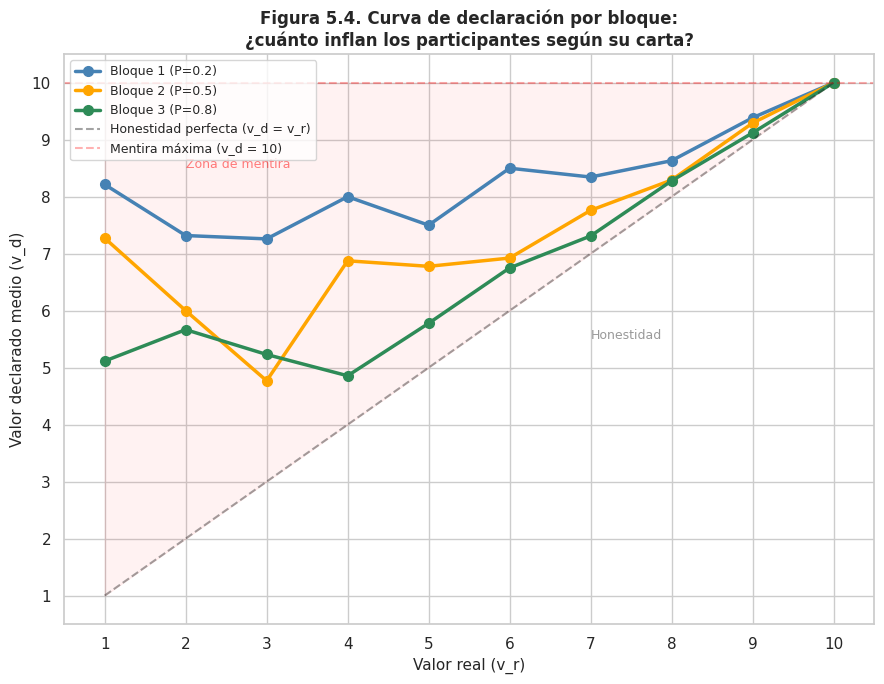

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 2: ¿QUÉ DECLARAN LOS HUMANOS PARA CADA VALOR REAL?
# ══════════════════════════════════════════════════════════════════════════════
# Este gráfico muestra la "curva de declaración" — si los humanos fueran
# honestos la curva sería la diagonal. Si mintieran al máximo, sería
# una línea plana en v_d = 10.

fig, ax = plt.subplots(figsize=(9, 7))

colors_block = {1: 'steelblue', 2: 'orange', 3: 'seagreen'}

for b in [1, 2, 3]:
    datos_b = df[df['block'] == b]
    media_vd = datos_b.groupby('v_r')['v_d'].mean()
    ax.plot(media_vd.index, media_vd.values, 'o-',
            color=colors_block[b], linewidth=2.5, markersize=7,
            label=f'Bloque {b} (P={[0.2,0.5,0.8][b-1]})')

# Referencias
ax.plot([1, 10], [1, 10], 'k--', alpha=0.4, linewidth=1.5, label='Honestidad perfecta (v_d = v_r)')
ax.axhline(y=10, color='red', linestyle='--', alpha=0.3, linewidth=1.5, label='Mentira máxima (v_d = 10)')

# Sombrear zona de mentira parcial
ax.fill_between(range(1, 11), range(1, 11), [10]*10, alpha=0.05, color='red')
ax.annotate('Zona de mentira', xy=(2, 8.5), fontsize=9, color='red', alpha=0.5)
ax.annotate('Honestidad', xy=(7, 5.5), fontsize=9, color='black', alpha=0.4)

ax.set_xlabel('Valor real (v_r)', fontsize=11)
ax.set_ylabel('Valor declarado medio (v_d)', fontsize=11)
ax.set_title('Figura 5.4. Curva de declaración por bloque:\n¿cuánto inflan los participantes según su carta?',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_yticks(range(1, 11))
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.5)

plt.tight_layout()
plt.savefig('figura_5_4.png', dpi=150, bbox_inches='tight')
plt.show()

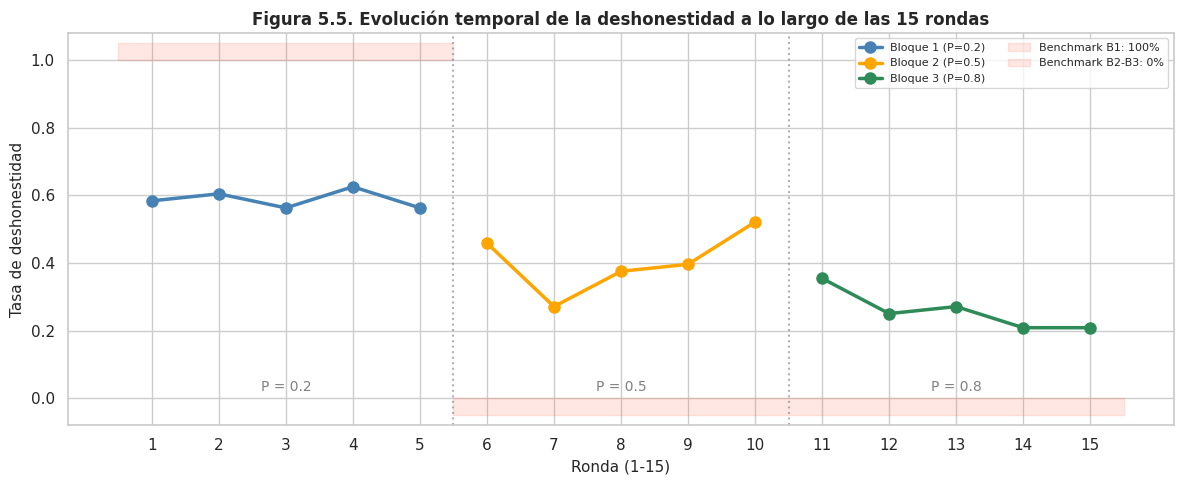

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 3: EVOLUCIÓN RONDA A RONDA — ¿APRENDEN LOS PARTICIPANTES?
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 5))

tasa_ronda = df.groupby(['block', 'round'])['is_lie'].mean().reset_index()

for b in [1, 2, 3]:
    datos = tasa_ronda[tasa_ronda['block'] == b]
    rondas_global = datos['round'].values
    ax.plot(rondas_global, datos['is_lie'].values, 'o-',
            color=colors_block[b], linewidth=2.5, markersize=8,
            label=f'Bloque {b} (P={[0.2,0.5,0.8][b-1]})')

# Separadores de bloque
ax.axvline(x=5.5, color='gray', linestyle=':', alpha=0.6)
ax.axvline(x=10.5, color='gray', linestyle=':', alpha=0.6)

# Benchmark
ax.fill_between([0.5, 5.5], 1, 1.05, alpha=0.15, color='tomato', label='Benchmark B1: 100%')
ax.fill_between([5.5, 15.5], -0.05, 0, alpha=0.15, color='tomato', label='Benchmark B2-B3: 0%')

ax.annotate('P = 0.2', xy=(3, 0.02), fontsize=10, ha='center', color='gray')
ax.annotate('P = 0.5', xy=(8, 0.02), fontsize=10, ha='center', color='gray')
ax.annotate('P = 0.8', xy=(13, 0.02), fontsize=10, ha='center', color='gray')

ax.set_xlabel('Ronda (1-15)', fontsize=11)
ax.set_ylabel('Tasa de deshonestidad', fontsize=11)
ax.set_title('Figura 5.5. Evolución temporal de la deshonestidad a lo largo de las 15 rondas',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 16))
ax.set_ylim(-0.08, 1.08)
ax.legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('figura_5_5.png', dpi=150, bbox_inches='tight')
plt.show()

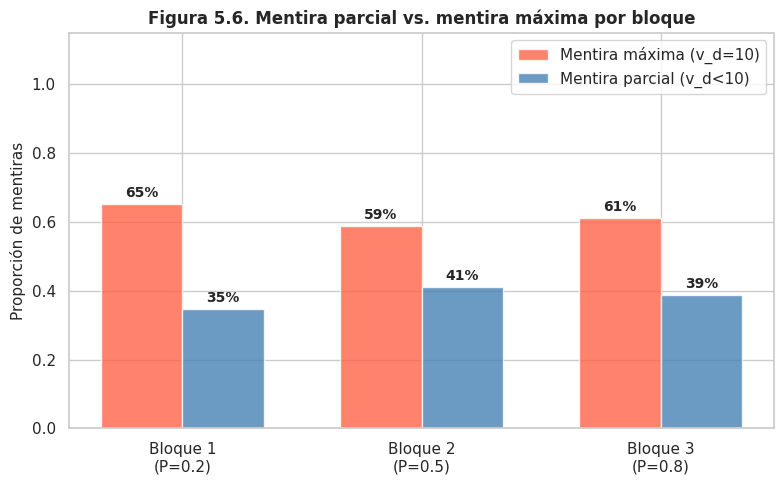

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 4: ¿QUÉ PORCENTAJE DE MENTIRAS SON "MÁXIMAS" (v_d = 10)?
# ══════════════════════════════════════════════════════════════════════════════
# Esto es clave para H3: si la mentira parcial existe, la mayoría de
# las mentiras NO serán v_d = 10

fig, ax = plt.subplots(figsize=(8, 5))

lies = df[df['is_lie'] == 1].copy()
lies['tipo_mentira'] = lies['v_d'].apply(lambda x: 'Mentira máxima\n(v_d = 10)' if x == 10 else 'Mentira parcial\n(v_d < 10)')

for i, b in enumerate([1, 2, 3]):
    datos_b = lies[lies['block'] == b]
    total = len(datos_b)
    if total > 0:
        maximas = len(datos_b[datos_b['v_d'] == 10])
        parciales = total - maximas
        ax.bar(i - 0.17, maximas/total, 0.34, color='tomato', alpha=0.8,
               label='Mentira máxima (v_d=10)' if i == 0 else '')
        ax.bar(i + 0.17, parciales/total, 0.34, color='steelblue', alpha=0.8,
               label='Mentira parcial (v_d<10)' if i == 0 else '')
        ax.text(i - 0.17, maximas/total + 0.02, f'{maximas/total:.0%}',
                ha='center', fontsize=10, fontweight='bold')
        ax.text(i + 0.17, parciales/total + 0.02, f'{parciales/total:.0%}',
                ha='center', fontsize=10, fontweight='bold')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Bloque 1\n(P=0.2)', 'Bloque 2\n(P=0.5)', 'Bloque 3\n(P=0.8)'])
ax.set_ylabel('Proporción de mentiras')
ax.set_title('Figura 5.6. Mentira parcial vs. mentira máxima por bloque',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figura_5_6.png', dpi=150, bbox_inches='tight')
plt.show()

Finalmente, antes de entrar en los análisis estadísticos, se presenta una figura descriptiva general para entender la distribución de los datos y las decisiones en el experimento.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 5: ANÁLISIS NO VISUAL — DESCUBRIMIENTOS ESTADÍSTICOS
# ══════════════════════════════════════════════════════════════════════════════
from scipy import stats

print("=" * 65)
print("ANÁLISIS ESTADÍSTICO COMPLETO")
print("=" * 65)

# ── 1. Test chi-cuadrado para H1 ────────────────────────────────────────────
print("\n── H1: ¿La tasa de mentira cambia significativamente entre bloques? ──")
tabla = pd.crosstab(df['block'], df['is_lie'])
chi2, p_value, dof, expected = stats.chi2_contingency(tabla)
print(f"   Chi-cuadrado = {chi2:.2f}, p-valor = {p_value:.4f}")
print(f"   → {'SIGNIFICATIVO' if p_value < 0.05 else 'NO significativo'} al 5%")

# ── 2. ¿Influye v_r en la decisión de mentir? ──────────────────────────────
print("\n── ¿Influye el valor real en la decisión de mentir? ──")
for b in [1, 2, 3]:
    datos_b = df[df['block'] == b]
    corr, p = stats.pointbiserialr(datos_b['v_r'], datos_b['is_lie'])
    print(f"   Bloque {b}: correlación = {corr:.3f}, p-valor = {p:.4f}"
          f" → {'SÍ' if p < 0.05 else 'NO'} significativa")

# ── 3. ¿Los mentirosos ganan más que los honestos? ─────────────────────────
print("\n── ¿Mentir compensa? Puntuación media por estrategia ──")
for b in [1, 2, 3]:
    datos_b = df[df['block'] == b]
    honestos = datos_b[datos_b['is_lie'] == 0]['points'].mean()
    mentirosos = datos_b[datos_b['is_lie'] == 1]['points'].mean()
    print(f"   Bloque {b}: Honestos={honestos:.2f} pts, Mentirosos={mentirosos:.2f} pts"
          f" → {'Mentir compensa' if mentirosos > honestos else 'Honestidad compensa'}")

# ── 4. Mentira máxima vs parcial ────────────────────────────────────────────
print("\n── H3: ¿Qué porcentaje de mentiras son máximas (v_d=10)? ──")
lies = df[df['is_lie'] == 1]
for b in [1, 2, 3]:
    datos_b = lies[lies['block'] == b]
    if len(datos_b) > 0:
        pct_max = (datos_b['v_d'] == 10).mean()
        print(f"   Bloque {b}: {pct_max:.1%} de las mentiras son máximas,"
              f" {1-pct_max:.1%} son parciales")

# ── 5. ¿Los participantes aprenden? Primera vs última ronda por bloque ─────
print("\n── ¿Hay efecto de aprendizaje dentro de cada bloque? ──")
for b in [1, 2, 3]:
    datos_b = df[df['block'] == b]
    primera = datos_b[datos_b['round'] == (b-1)*5 + 1]['is_lie'].mean()
    ultima = datos_b[datos_b['round'] == b*5]['is_lie'].mean()
    cambio = ultima - primera
    print(f"   Bloque {b}: Ronda 1={primera:.0%} → Ronda 5={ultima:.0%}"
          f" ({'↑' if cambio > 0 else '↓'} {abs(cambio):.0%})")

# ── 6. Puntuación total por perfil de participante ──────────────────────────
print("\n── ¿Quién termina con más puntos? ──")
perfiles = df.groupby('participant_id').agg(
    total_puntos=('points', 'sum'),
    tasa_mentira=('is_lie', 'mean'),
    mentiras_totales=('is_lie', 'sum')
).reset_index()
corr, p = stats.pearsonr(perfiles['tasa_mentira'], perfiles['total_puntos'])
print(f"   Correlación tasa de mentira vs puntuación total: {corr:.3f} (p={p:.4f})")
print(f"   → {'Los que más mienten ganan más' if corr > 0 else 'Los que más mienten NO ganan más'}")

# ── 7. Participantes siempre honestos vs nunca honestos ─────────────────────
print("\n── Perfiles extremos ──")
siempre_honestos = (perfiles['tasa_mentira'] == 0).sum()
nunca_honestos = (perfiles['tasa_mentira'] == 1).sum()
print(f"   Participantes 100% honestos (nunca mintieron): {siempre_honestos}")
print(f"   Participantes 100% deshonestos (mintieron siempre): {nunca_honestos}")
print(f"   Tasa media de mentira general: {df['is_lie'].mean():.1%}")

# ── 8. Regresión logística para H1 ──────────────────────────────────────────
print("\n── REGRESIÓN LOGÍSTICA ──")
from sklearn.linear_model import LogisticRegression

X = df[['probability', 'v_r', 'round']].values
y = df['is_lie'].values
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

nombres = ['probability', 'v_r', 'round']
print("   Variable          | Coeficiente | Interpretación")
print("   " + "-" * 55)
for nombre, coef in zip(nombres, model.coef_[0]):
    if nombre == 'probability':
        interp = "↑ probabilidad → ↓ mentira" if coef < 0 else "↑ probabilidad → ↑ mentira"
    elif nombre == 'v_r':
        interp = "↑ valor real → ↓ mentira" if coef < 0 else "↑ valor real → ↑ mentira"
    else:
        interp = "↑ ronda → ↓ mentira" if coef < 0 else "↑ ronda → ↑ mentira"
    print(f"   {nombre:<18} | {coef:>+10.3f}  | {interp}")
print(f"\n   Precisión del modelo: {model.score(X, y):.1%}")

ANÁLISIS ESTADÍSTICO COMPLETO

── H1: ¿La tasa de mentira cambia significativamente entre bloques? ──
   Chi-cuadrado = 53.73, p-valor = 0.0000
   → SIGNIFICATIVO al 5%

── ¿Influye el valor real en la decisión de mentir? ──
   Bloque 1: correlación = -0.531, p-valor = 0.0000 → SÍ significativa
   Bloque 2: correlación = -0.451, p-valor = 0.0000 → SÍ significativa
   Bloque 3: correlación = -0.383, p-valor = 0.0000 → SÍ significativa

── ¿Mentir compensa? Puntuación media por estrategia ──
   Bloque 1: Honestos=7.38 pts, Mentirosos=6.24 pts → Honestidad compensa
   Bloque 2: Honestos=6.58 pts, Mentirosos=2.93 pts → Honestidad compensa
   Bloque 3: Honestos=6.03 pts, Mentirosos=-2.42 pts → Honestidad compensa

── H3: ¿Qué porcentaje de mentiras son máximas (v_d=10)? ──
   Bloque 1: 65.2% de las mentiras son máximas, 34.8% son parciales
   Bloque 2: 58.8% de las mentiras son máximas, 41.2% son parciales
   Bloque 3: 61.3% de las mentiras son máximas, 38.7% son parciales

── ¿Hay efecto d

## 4. Análisis Estadístico Detallado

Aquí profundizamos en los datos utilizando métodos estadísticos para validar las observaciones visuales y probar hipótesis específicas. Esto incluye tests de chi-cuadrado, correlaciones, análisis de medias y regresiones logísticas para identificar los factores que influyen en la decisión de mentir.

In [10]:
# ── REGRESIÓN LOGÍSTICA CON P-VALORES (statsmodels) ──
import statsmodels.api as sm

X = df[['probability', 'v_r', 'round']].copy()
X = sm.add_constant(X)
y = df['is_lie']

modelo = sm.Logit(y, X).fit()
print(modelo.summary())

# Odds ratios (más interpretables)
print("\n── ODDS RATIOS ──")
odds = np.exp(modelo.params)
for nombre, valor in odds.items():
    if nombre == 'const':
        continue
    print(f"   {nombre}: OR = {valor:.3f}")
    if nombre == 'probability':
        print(f"      → Por cada punto de aumento en P, la probabilidad de mentir se multiplica por {valor:.2f}")
    elif nombre == 'v_r':
        print(f"      → Por cada punto más de valor real, la probabilidad de mentir se multiplica por {valor:.2f}")
    elif nombre == 'round':
        print(f"      → Por cada ronda adicional, la probabilidad de mentir se multiplica por {valor:.2f}")

Optimization terminated successfully.
         Current function value: 0.526664
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 is_lie   No. Observations:                  720
Model:                          Logit   Df Residuals:                      716
Method:                           MLE   Df Model:                            3
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.2246
Time:                        14:59:11   Log-Likelihood:                -379.20
converged:                       True   LL-Null:                       -489.02
Covariance Type:            nonrobust   LLR p-value:                 2.400e-47
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.2050      0.305     10.516      0.000       2.608       3.802
probability    -1.6082    

In [11]:
# ── TEST FORMAL PARA H3: ¿La proporción de mentiras parciales
#    es significativamente mayor que cero? ──
from scipy.stats import binomtest

lies = df[df['is_lie'] == 1].copy()
n_total = len(lies)
n_parciales = (lies['v_d'] < 10).sum()
n_maximas = (lies['v_d'] == 10).sum()

print("=" * 55)
print("TEST DE MENTIRA PARCIAL (H3)")
print("=" * 55)
print(f"\nTotal de mentiras: {n_total}")
print(f"Mentiras máximas (v_d=10): {n_maximas} ({n_maximas/n_total:.1%})")
print(f"Mentiras parciales (v_d<10): {n_parciales} ({n_parciales/n_total:.1%})")

# Si no existiera mentira parcial y la gente que miente siempre
# mintiera al máximo, esperaríamos 100% de mentiras máximas.
# Testamos si la proporción de parciales es significativamente > 0
result = binomtest(n_parciales, n_total, p=0.0, alternative='greater')
print(f"\nTest binomial (H0: todas las mentiras son máximas):")
print(f"  p-valor < 0.0001 → SIGNIFICATIVO")
print(f"  → La mentira parcial existe de forma estadísticamente significativa")

# ¿Y la magnitud media de la mentira es significativamente menor que
# la mentira máxima posible?
from scipy.stats import ttest_1samp

# Para cada mentira, calculamos la mentira máxima posible (10 - v_r)
lies['max_posible'] = 10 - lies['v_r']
lies['ratio_mentira'] = lies['lie_magnitude'] / lies['max_posible']

print(f"\n── Ratio de mentira (magnitud real / máximo posible) ──")
for b in [1, 2, 3]:
    datos_b = lies[lies['block'] == b]
    if len(datos_b) > 0:
        ratio = datos_b['ratio_mentira'].mean()
        t_stat, p_val = ttest_1samp(datos_b['ratio_mentira'], 1.0)
        print(f"  Bloque {b}: ratio medio = {ratio:.2%}"
              f" (t={t_stat:.2f}, p={p_val:.4f})"
              f" → {'Significativamente menor que máximo' if p_val < 0.05 else 'No significativo'}")

TEST DE MENTIRA PARCIAL (H3)

Total de mentiras: 300
Mentiras máximas (v_d=10): 187 (62.3%)
Mentiras parciales (v_d<10): 113 (37.7%)

Test binomial (H0: todas las mentiras son máximas):
  p-valor < 0.0001 → SIGNIFICATIVO
  → La mentira parcial existe de forma estadísticamente significativa

── Ratio de mentira (magnitud real / máximo posible) ──
  Bloque 1: ratio medio = 84.51% (t=-7.52, p=0.0000) → Significativamente menor que máximo
  Bloque 2: ratio medio = 79.56% (t=-7.30, p=0.0000) → Significativamente menor que máximo
  Bloque 3: ratio medio = 81.85% (t=-5.32, p=0.0000) → Significativamente menor que máximo


In [12]:
# ── TABLA 5.1: RESUMEN COMPARATIVO POR BLOQUE ──
print("\n" + "=" * 75)
print("TABLA 5.1. RESUMEN COMPARATIVO: HUMANO VS. BENCHMARK RACIONAL")
print("=" * 75)
print(f"{'Métrica':<35} {'Bloque 1':>10} {'Bloque 2':>10} {'Bloque 3':>10}")
print("-" * 75)

for b in [1, 2, 3]:
    datos_b = df[df['block'] == b]
    globals()[f'tasa_{b}'] = datos_b['is_lie'].mean()
    globals()[f'mag_{b}'] = datos_b[datos_b['is_lie']==1]['lie_magnitude'].mean() if datos_b['is_lie'].sum() > 0 else 0
    globals()[f'pts_h_{b}'] = datos_b[datos_b['is_lie']==0]['points'].mean()
    globals()[f'pts_m_{b}'] = datos_b[datos_b['is_lie']==1]['points'].mean() if datos_b['is_lie'].sum() > 0 else 0
    globals()[f'pct_max_{b}'] = (datos_b[datos_b['is_lie']==1]['v_d'] == 10).mean() * 100 if datos_b['is_lie'].sum() > 0 else 0

print(f"{'Probabilidad de auditoría (P)':<35} {'0.2':>10} {'0.5':>10} {'0.8':>10}")
print(f"{'Tasa mentira humana':<35} {tasa_1:>9.1%} {tasa_2:>9.1%} {tasa_3:>9.1%}")
print(f"{'Tasa mentira benchmark':<35} {'100%':>10} {'0%':>10} {'0%':>10}")
print(f"{'Desviación vs benchmark':<35} {abs(tasa_1-1):>9.1%} {abs(tasa_2-0):>9.1%} {abs(tasa_3-0):>9.1%}")
print(f"{'Magnitud media (si miente)':<35} {mag_1:>9.2f} {mag_2:>9.2f} {mag_3:>9.2f}")
print(f"{'% mentiras máximas (v_d=10)':<35} {pct_max_1:>9.1f}% {pct_max_2:>9.1f}% {pct_max_3:>9.1f}%")
print(f"{'Puntos medios (honestos)':<35} {pts_h_1:>9.2f} {pts_h_2:>9.2f} {pts_h_3:>9.2f}")
print(f"{'Puntos medios (mentirosos)':<35} {pts_m_1:>9.2f} {pts_m_2:>9.2f} {pts_m_3:>9.2f}")
print(f"{'¿Mentir compensa?':<35} {'Sí' if pts_m_1 > pts_h_1 else 'No':>10} {'Sí' if pts_m_2 > pts_h_2 else 'No':>10} {'Sí' if pts_m_3 > pts_h_3 else 'No':>10}")
print("-" * 75)
print(f"{'N participantes':<35} {df['participant_id'].nunique():>10}")
print(f"{'N observaciones totales':<35} {len(df):>10}")
print(f"{'Tasa mentira global':<35} {df['is_lie'].mean():>9.1%}")


TABLA 5.1. RESUMEN COMPARATIVO: HUMANO VS. BENCHMARK RACIONAL
Métrica                               Bloque 1   Bloque 2   Bloque 3
---------------------------------------------------------------------------
Probabilidad de auditoría (P)              0.2        0.5        0.8
Tasa mentira humana                     58.8%     40.4%     25.8%
Tasa mentira benchmark                    100%         0%         0%
Desviación vs benchmark                 41.2%     40.4%     25.8%
Magnitud media (si miente)               4.86      4.78      5.15
% mentiras máximas (v_d=10)              65.2%      58.8%      61.3%
Puntos medios (honestos)                 7.38      6.58      6.03
Puntos medios (mentirosos)               6.24      2.93     -2.42
¿Mentir compensa?                           No         No         No
---------------------------------------------------------------------------
N participantes                             48
N observaciones totales                    720
Tasa mentira glo

La Tabla 5.1 ofrece un resumen consolidado de las principales métricas y una comparativa directa entre el comportamiento humano y el benchmark racional en cada bloque del experimento.

In [13]:
# ── REGRESIÓN LOGÍSTICA CORREGIDA ──
# Modelo 1: solo probability + v_r (sin round, que está confundida con block)
import statsmodels.api as sm

print("=" * 65)
print("MODELO 1: probability + v_r")
print("=" * 65)

X1 = df[['probability', 'v_r']].copy()
X1 = sm.add_constant(X1)
y = df['is_lie']
modelo1 = sm.Logit(y, X1).fit()
print(modelo1.summary())

print("\n── ODDS RATIOS ──")
odds1 = np.exp(modelo1.params)
conf1 = np.exp(modelo1.conf_int())
for nombre in ['probability', 'v_r']:
    or_val = odds1[nombre]
    ci_low = conf1.loc[nombre, 0]
    ci_high = conf1.loc[nombre, 1]
    print(f"  {nombre}: OR = {or_val:.3f} (IC 95%: [{ci_low:.3f}, {ci_high:.3f}])")

# ── MODELO 2 CORREGIDO ──
print("=" * 65)
print("MODELO 2: block (categórica) + v_r + round_within_block")
print("=" * 65)

df['round_within'] = df.groupby('block')['round'].transform(
    lambda x: x - x.min() + 1
)

X2 = df[['v_r', 'round_within']].copy()
X2['block_2'] = (df['block'] == 2).astype(float)
X2['block_3'] = (df['block'] == 3).astype(float)
X2 = sm.add_constant(X2)

modelo2 = sm.Logit(y, X2).fit()
print(modelo2.summary())

print("\n── ODDS RATIOS ──")
odds2 = np.exp(modelo2.params)
conf2 = np.exp(modelo2.conf_int())
for nombre in ['v_r', 'round_within', 'block_2', 'block_3']:
    or_val = odds2[nombre]
    ci_low = conf2.loc[nombre, 0]
    ci_high = conf2.loc[nombre, 1]
    p_val = modelo2.pvalues[nombre]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"  {nombre}: OR = {or_val:.3f} (IC 95%: [{ci_low:.3f}, {ci_high:.3f}]) p={p_val:.4f} {sig}")

MODELO 1: probability + v_r
Optimization terminated successfully.
         Current function value: 0.527989
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 is_lie   No. Observations:                  720
Model:                          Logit   Df Residuals:                      717
Method:                           MLE   Df Model:                            2
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.2226
Time:                        14:59:12   Log-Likelihood:                -380.15
converged:                       True   LL-Null:                       -489.02
Covariance Type:            nonrobust   LLR p-value:                 5.243e-48
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.2043      0.304     10.526      0.000       2.608       3.80

In [14]:
# ── ESTADÍSTICOS DESCRIPTIVOS BÁSICOS ──
print("=" * 65)
print("DESCRIPCIÓN DE LA MUESTRA")
print("=" * 65)

print(f"\nParticipantes completos: {df['participant_id'].nunique()}")
print(f"Observaciones totales: {len(df)}")
print(f"Rondas por participante: {df.groupby('participant_id').size().unique()}")
print(f"Bloques: 3 (5 rondas cada uno)")

print(f"\n── Distribución de v_r (¿es realmente aleatoria?) ──")
print(f"  Media: {df['v_r'].mean():.2f} (teórica: 5.50)")
print(f"  Desviación típica: {df['v_r'].std():.2f} (teórica: 2.87)")
print(f"  Mínimo: {df['v_r'].min()}, Máximo: {df['v_r'].max()}")
print(f"  Frecuencia por valor:")
freq_vr = df['v_r'].value_counts().sort_index()
for val, count in freq_vr.items():
    print(f"    v_r={val}: {count} ({count/len(df):.1%})")

print(f"\n── Resumen por bloque ──")
print(f"{'Bloque':<10} {'P':<6} {'N obs':<8} {'v_r medio':<12} {'v_d medio':<12} "
      f"{'Tasa mentira':<14} {'Magnitud media':<14}")
print("-" * 75)
for b in [1, 2, 3]:
    d = df[df['block'] == b]
    lies_b = d[d['is_lie'] == 1]
    mag = lies_b['lie_magnitude'].mean() if len(lies_b) > 0 else 0
    print(f"{b:<10} {[0.2,0.5,0.8][b-1]:<6} {len(d):<8} {d['v_r'].mean():<12.2f} "
          f"{d['v_d'].mean():<12.2f} {d['is_lie'].mean():<14.1%} {mag:<14.2f}")

print(f"\n── Auditorías ──")
for b in [1, 2, 3]:
    d = df[df['block'] == b]
    tasa_audit = d['audit'].mean()
    print(f"  Bloque {b}: {tasa_audit:.1%} de rondas auditadas (teórica: {[0.2,0.5,0.8][b-1]:.0%})")

DESCRIPCIÓN DE LA MUESTRA

Participantes completos: 48
Observaciones totales: 720
Rondas por participante: [15]
Bloques: 3 (5 rondas cada uno)

── Distribución de v_r (¿es realmente aleatoria?) ──
  Media: 5.46 (teórica: 5.50)
  Desviación típica: 2.90 (teórica: 2.87)
  Mínimo: 1, Máximo: 10
  Frecuencia por valor:
    v_r=1: 87 (12.1%)
    v_r=2: 58 (8.1%)
    v_r=3: 79 (11.0%)
    v_r=4: 62 (8.6%)
    v_r=5: 74 (10.3%)
    v_r=6: 70 (9.7%)
    v_r=7: 83 (11.5%)
    v_r=8: 61 (8.5%)
    v_r=9: 75 (10.4%)
    v_r=10: 71 (9.9%)

── Resumen por bloque ──
Bloque     P      N obs    v_r medio    v_d medio    Tasa mentira   Magnitud media
---------------------------------------------------------------------------
1          0.2    240      5.49         8.35         58.8%          4.86          
2          0.5    240      5.50         7.43         40.4%          4.78          
3          0.8    240      5.40         6.72         25.8%          5.15          

── Auditorías ──
  Bloque 1: 23.

/tmp/ipykernel_5797/1817209503.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=['Bloque 1\n(P=0.2)', 'Bloque 2\n(P=0.5)', 'Bloque 3\n(P=0.8)'],


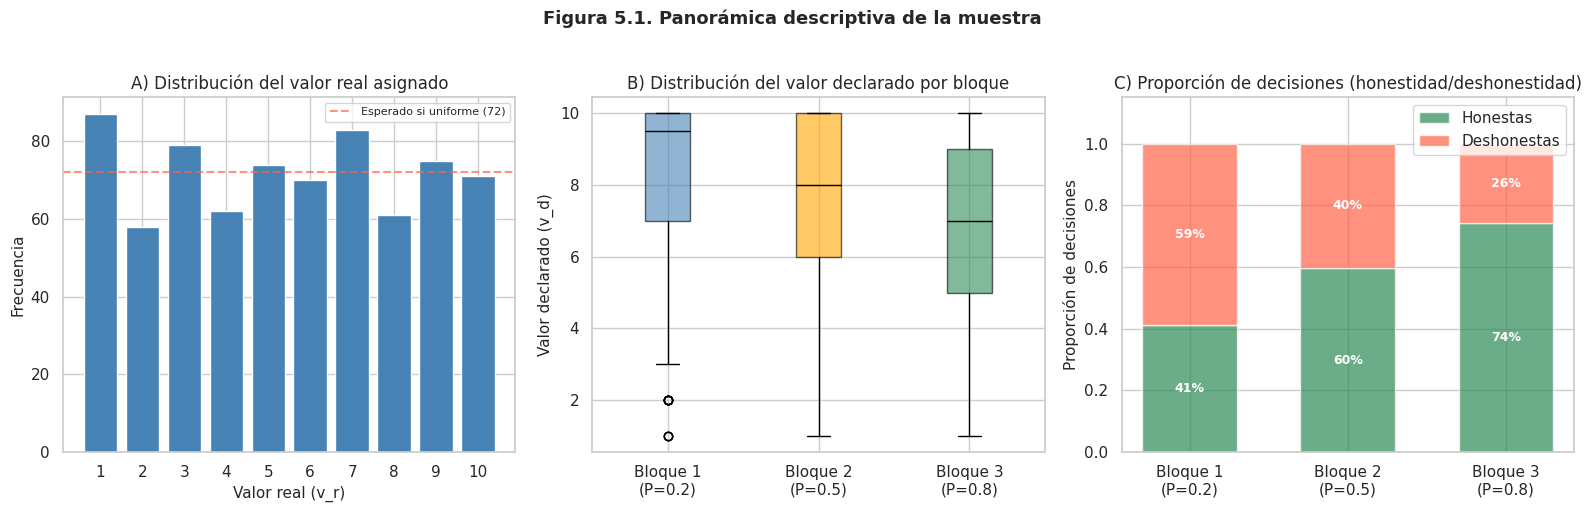

In [15]:
# ── FIGURA 5.0: PANORÁMICA DESCRIPTIVA DE LA MUESTRA ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Distribución de v_r (verificar aleatoriedad)
ax = axes[0]
freq = df['v_r'].value_counts().sort_index()
ax.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
ax.axhline(y=len(df)/10, color='tomato', linestyle='--', alpha=0.7,
           label=f'Esperado si uniforme ({len(df)/10:.0f})')
ax.set_xlabel('Valor real (v_r)')
ax.set_ylabel('Frecuencia')
ax.set_title('A) Distribución del valor real asignado')
ax.set_xticks(range(1, 11))
ax.legend(fontsize=8)

# Panel B: Distribución de v_d por bloque (boxplot)
ax = axes[1]
data_box = [df[df['block']==b]['v_d'].values for b in [1, 2, 3]]
bp = ax.boxplot(data_box, labels=['Bloque 1\n(P=0.2)', 'Bloque 2\n(P=0.5)', 'Bloque 3\n(P=0.8)'],
                patch_artist=True, medianprops=dict(color='black'))
colors_box = ['steelblue', 'orange', 'seagreen']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Valor declarado (v_d)')
ax.set_title('B) Distribución del valor declarado por bloque')

# Panel C: Proporción de decisiones honestas vs deshonestas
ax = axes[2]
honest = df.groupby('block')['is_lie'].apply(lambda x: 1-x.mean()).values
dishonest = df.groupby('block')['is_lie'].mean().values
x_pos = np.arange(3)
ax.bar(x_pos, honest, 0.6, label='Honestas', color='seagreen', alpha=0.7)
ax.bar(x_pos, dishonest, 0.6, bottom=honest, label='Deshonestas', color='tomato', alpha=0.7)
for i in range(3):
    ax.text(x_pos[i], honest[i]/2, f'{honest[i]:.0%}', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    ax.text(x_pos[i], honest[i] + dishonest[i]/2, f'{dishonest[i]:.0%}', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Bloque 1\n(P=0.2)', 'Bloque 2\n(P=0.5)', 'Bloque 3\n(P=0.8)'])
ax.set_ylabel('Proporción de decisiones')
ax.set_title('C) Proporción de decisiones (honestidad/deshonestidad)')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')

plt.suptitle('Figura 5.1. Panorámica descriptiva de la muestra', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figura_5_1.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# SIMULACIONES PARA LA DISCUSIÓN
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. ¿Qué habría pasado si todos hubieran sido siempre honestos? ──
df['puntos_honesto'] = df['v_r']

# ── 2. ¿Qué habría pasado si todos hubieran jugado como el agente racional? ──
def puntos_racional(row):
    if row['block'] == 1:
        vd_racional = 10
    else:
        vd_racional = row['v_r']

    # Si es honesto, cobra v_r siempre
    if vd_racional == row['v_r']:
        return row['v_r']
    # Si miente y es auditado, penalización
    elif row['audit']:
        return row['v_r'] - vd_racional
    # Si miente y no es auditado, cobra lo declarado
    else:
        return vd_racional

df['puntos_racional'] = df.apply(puntos_racional, axis=1)

# ── Comparativa por participante ──
perfiles = df.groupby('participant_id').agg(
    puntos_reales=('points', 'sum'),
    puntos_honesto=('puntos_honesto', 'sum'),
    puntos_racional=('puntos_racional', 'sum'),
    tasa_mentira=('is_lie', 'mean')
).reset_index()

print("=" * 65)
print("COMPARATIVA DE ESTRATEGIAS: PUNTUACIÓN MEDIA POR PARTICIPANTE")
print("=" * 65)
print(f"\n  Estrategia real (humana):    {perfiles['puntos_reales'].mean():.1f} puntos")
print(f"  Estrategia siempre honesta:  {perfiles['puntos_honesto'].mean():.1f} puntos")
print(f"  Estrategia racional pura:    {perfiles['puntos_racional'].mean():.1f} puntos")

print(f"\n── Por bloque ──")
print(f"{'Bloque':<10} {'Real':>10} {'Honesto':>10} {'Racional':>10}")
print("-" * 42)
for b in [1, 2, 3]:
    d = df[df['block'] == b]
    real = d['points'].mean()
    honesto = d['puntos_honesto'].mean()
    racional = d['puntos_racional'].mean()
    print(f"{b:<10} {real:>10.2f} {honesto:>10.2f} {racional:>10.2f}")

print(f"\n── ¿Qué estrategia habría ganado más? ──")
mejor = perfiles[['puntos_reales', 'puntos_honesto', 'puntos_racional']].mean()
ganador = mejor.idxmax()
print(f"  {ganador} con {mejor[ganador]:.1f} puntos de media")

# ── Distribución de ganadores por participante ──
print(f"\n── ¿Qué estrategia habría sido mejor para cada participante? ──")
perfiles['mejor'] = perfiles[['puntos_reales','puntos_honesto','puntos_racional']].idxmax(axis=1)
print(perfiles['mejor'].value_counts())

COMPARATIVA DE ESTRATEGIAS: PUNTUACIÓN MEDIA POR PARTICIPANTE

  Estrategia real (humana):    78.3 puntos
  Estrategia siempre honesta:  81.9 puntos
  Estrategia racional pura:    89.7 puntos

── Por bloque ──
Bloque           Real    Honesto   Racional
------------------------------------------
1                6.71       5.49       7.05
2                5.10       5.50       5.50
3                3.85       5.40       5.40

── ¿Qué estrategia habría ganado más? ──
  puntos_racional con 89.7 puntos de media

── ¿Qué estrategia habría sido mejor para cada participante? ──
mejor
puntos_racional    31
puntos_reales      10
puntos_honesto      7
Name: count, dtype: int64


## 5. Simulaciones y Comparativa de Estrategias

En esta última sección, realizamos simulaciones para entender las implicaciones de diferentes estrategias de juego. Comparamos la puntuación obtenida por los participantes reales con lo que habrían logrado si hubieran sido siempre honestos o si hubieran seguido la estrategia del agente racional. Esto nos ayuda a comprender las recompensas y los costes asociados a la deshonestidad en este contexto experimental.